Training Shape: (49792, 160)
Testing Shape: (12448, 160)

Missing Values
108
0

After Removing Leakage Features
After Removing Extreme Features
(49792, 160)
(12448, 160)
(49792, 160)
(12448, 160)
Missing in Test:
set()

Missing in Train:
set()

Final Shapes
X_train: (49792, 160)
X_test : (12448, 160)


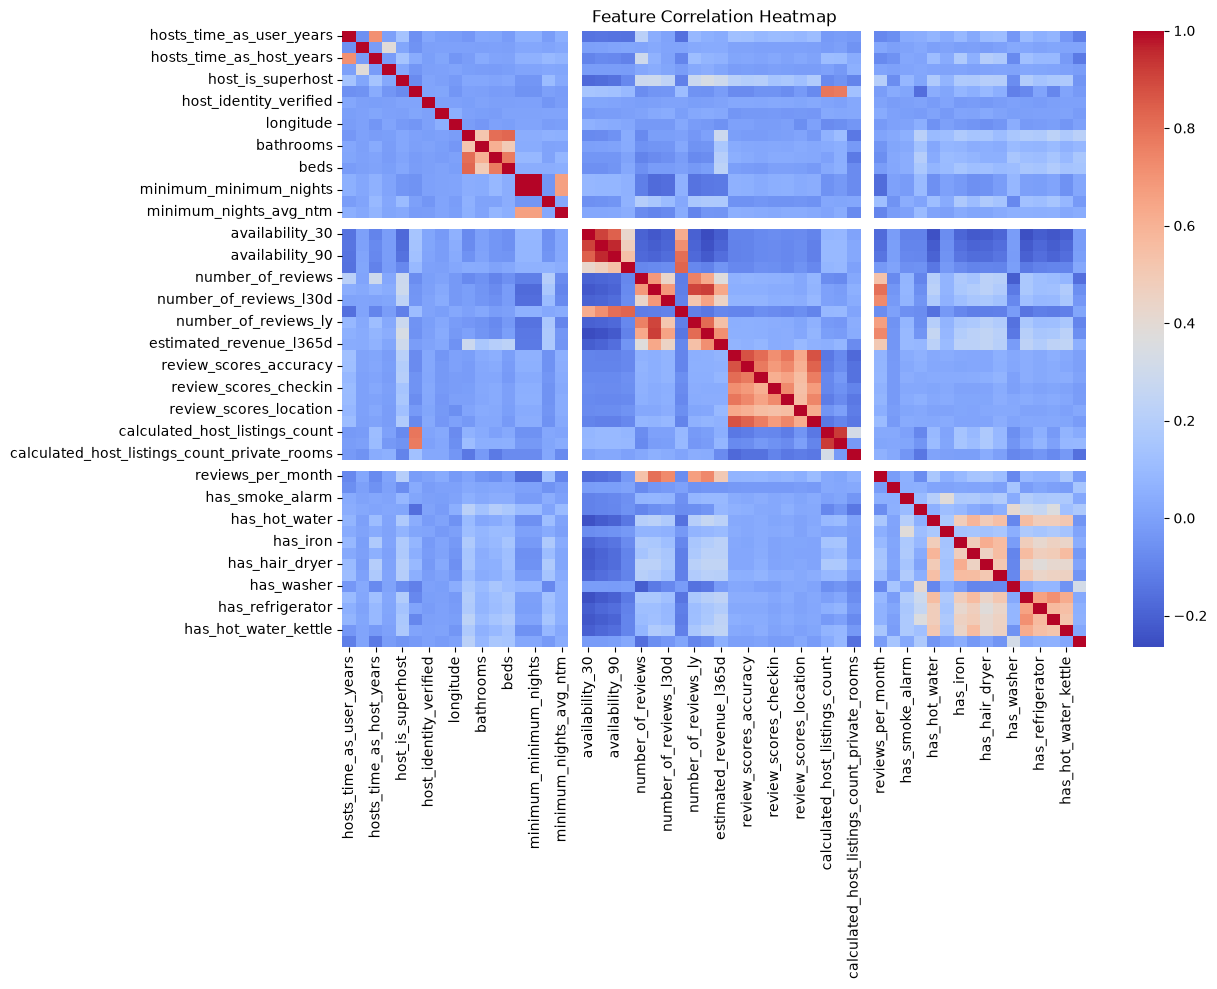

,Feature,Variance
estimated_revenue_l365d,estimated_revenue_l365d,5.215461e+08
maximum_maximum_nights,maximum_maximum_nights,1.616624e+05
availability_365,availability_365,1.427948e+04
estimated_occupancy_l365d,estimated_occupancy_l365d,6.905908e+03
host_listings_count,host_listings_count,6.225820e+03
availability_eoy,availability_eoy,3.673137e+03
number_of_reviews,number_of_reviews,2.668245e+03
calculated_host_listings_count,calculated_host_listings_count,9.099596e+02
availability_90,availability_90,8.077140e+02
calculated_host_listings_count_entire_homes,calculated_host_listings_count_entire_homes,7.932970e+02


,Feature,Importance
147,neighbourhood_grouped_Ealing,0.340673
9,accommodates,0.159755
32,review_scores_checkin,0.077043
11,bedrooms,0.068177
10,bathrooms,0.059923
31,review_scores_cleanliness,0.053963
8,longitude,0.028823
19,availability_60,0.023670
41,has_wifi,0.021524
7,latitude,0.020026


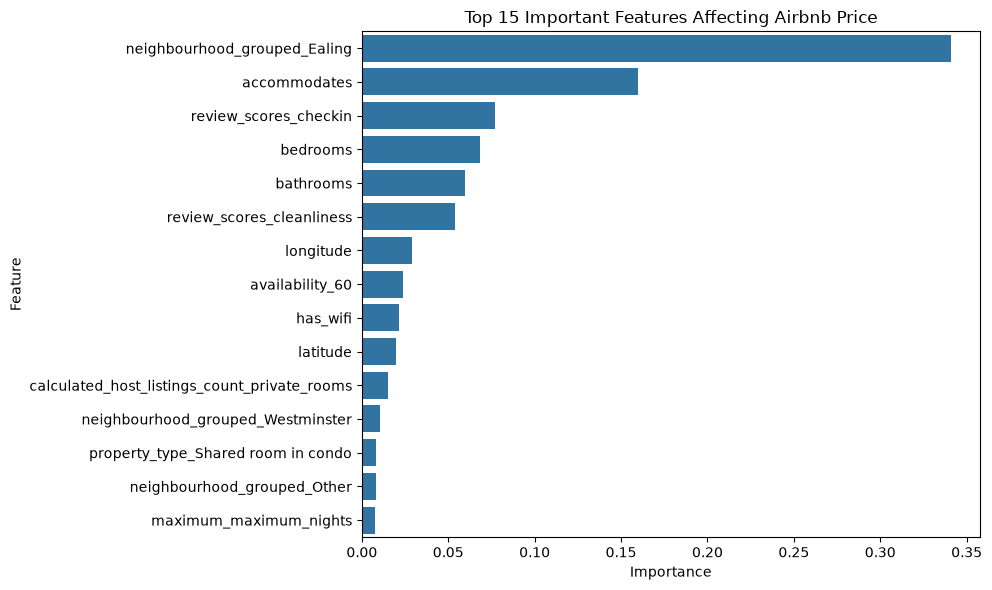

Feature Engineering Completed Successfully


In [14]:
# Feature Engineering Notebook
# Airbnb Price Prediction Project


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


# Load processed data

X_train = pd.read_csv(
    "../data/processed/X_train.csv"
)

X_test = pd.read_csv(
    "../data/processed/X_test.csv"
)


print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)



# Check missing values

print("\nMissing Values")
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())



# Remove columns with extremely large leakage possibility

remove_columns = [

    "price_quote_total_price",
    "estimated_revenue_1365d"

]


for col in remove_columns:

    if col in X_train.columns:

        X_train.drop(
            columns=[col],
            inplace=True
        )

    if col in X_test.columns:

        X_test.drop(
            columns=[col],
            inplace=True
        )



print("\nAfter Removing Leakage Features")
# Remove extreme outlier features

outlier_features = [
    "maximum_nights",
    "maximum_minimum_nights",
    "minimum_maximum_nights",
    "maximum_nights_avg_ntm"
]


for col in outlier_features:

    if col in X_train.columns:

        X_train.drop(
            columns=[col],
            inplace=True
        )

        X_test.drop(
            columns=[col],
            inplace=True
        )


print("After Removing Extreme Features")

print(X_train.shape)
print(X_test.shape)

print(
    X_train.shape
)

print(
    X_test.shape
)



# Ensure train and test have same columns

# Ensure train and test have identical features

missing_in_test = set(X_train.columns) - set(X_test.columns)

missing_in_train = set(X_test.columns) - set(X_train.columns)


print("Missing in Test:")
print(missing_in_test)


print("\nMissing in Train:")
print(missing_in_train)



# Add missing columns to test with zeros

for col in missing_in_test:
    X_test[col] = 0



# Remove extra columns from test

for col in missing_in_train:
    X_test.drop(
        columns=[col],
        inplace=True
    )



# Reorder columns

X_test = X_test[
    X_train.columns
]


print("\nFinal Shapes")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


# Correlation Analysis

numeric_features = X_train.select_dtypes(
    include=np.number
)



correlation = numeric_features.corr()



plt.figure(
    figsize=(12,8)
)


sns.heatmap(
    correlation,
    cmap="coolwarm"
)


plt.title(
    "Feature Correlation Heatmap"
)


plt.show()



# Feature variance analysis


variance = pd.DataFrame({

    "Feature":
    X_train.columns,

    "Variance":
    X_train.var()

})


variance = variance.sort_values(
    by="Variance",
    ascending=False
)


display(
    variance.head(20)
)



# Load trained model for feature importance


model = joblib.load(
    "../models/gradient_boosting_model.pkl"
)



# Feature importance using matching length

importance_length = min(
    len(X_train.columns),
    len(model.feature_importances_)
)


importance = pd.DataFrame({

    "Feature":
    X_train.columns[:importance_length],

    "Importance":
    model.feature_importances_[:importance_length]

})



importance = importance.sort_values(

    by="Importance",

    ascending=False

)



display(
    importance.head(15)
)




# Plot Feature Importance and Save Figure


plt.figure(
    figsize=(10,6)
)


sns.barplot(

    data=importance.head(15),

    x="Importance",

    y="Feature"

)


plt.title(
    "Top 15 Important Features Affecting Airbnb Price"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()


# Save figure for report

plt.savefig(
    "../figures/feature_importance_final.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# Save feature importance

importance.to_csv(

    "../data/processed/feature_importance.csv",

    index=False

)



# Save cleaned feature files again

X_train.to_csv(
    "../data/processed/X_train.csv",
    index=False
)


X_test.to_csv(
    "../data/processed/X_test.csv",
    index=False
)



print(
    "Feature Engineering Completed Successfully"
)

In [11]:
# Clip remaining numerical outliers

numeric_cols = X_train.select_dtypes(
    include=np.number
).columns


for col in numeric_cols:

    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.99)

    X_train[col] = X_train[col].clip(
        lower,
        upper
    )

    X_test[col] = X_test[col].clip(
        lower,
        upper
    )


print("Outlier clipping completed")

Outlier clipping completed


In [12]:
# Remove all price leakage features

leakage_features = [
    "price_quote_total_price",
    "price_quote_price_per_night",
    "estimated_revenue_1365d",
    "estimated_occupancy_1365d"
]


for col in leakage_features:
    if col in X_train.columns:
        X_train = X_train.drop(columns=[col])

    if col in X_test.columns:
        X_test = X_test.drop(columns=[col])


print("After leakage removal:")
print(X_train.shape)
print(X_test.shape)

After leakage removal:
(49792, 160)
(12448, 160)


In [13]:
X_train.to_csv(
    "../data/processed/X_train.csv",
    index=False
)

X_test.to_csv(
    "../data/processed/X_test.csv",
    index=False
)